In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
Runtime → Restart Session


In [1]:
## Importing the libraries
import tensorflow as tf
import os


2026-04-25 07:06:54.155526: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777100814.338345      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777100814.389840      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777100814.795444      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777100814.795482      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777100814.795484      55 computation_placer.cc:177] computation placer alr

In [2]:

## Tracing the path of dataset
train_dir = "/kaggle/input/datasets/disha1510/plant-disease-detection-dataset/train/Tomato"
val_dir   = "/kaggle/input/datasets/disha1510/plant-disease-detection-dataset/valid/Tomato"



In [3]:
## Importing the dataset

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=16,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)


Found 7399 files belonging to 4 classes.


I0000 00:00:1777100868.492586      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777100868.498600      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1849 files belonging to 4 classes.


In [4]:
for images, labels in train_ds.take(1):
    print(images[0].numpy().min(), images[0].numpy().max())


0.30611026 243.42314


In [5]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128,3,activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4,activation='softmax')
])


In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [7]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5


I0000 00:00:1777100888.896088     129 service.cc:152] XLA service 0x798b04005620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777100888.896124     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777100888.896130     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777100889.261703     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-25 07:08:11.080857: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 07:08:11.226420: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  7/463 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.2305 - loss: 1.4252

I0000 00:00:1777100893.469611     129 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5576 - loss: 0.9965

2026-04-25 07:08:27.934287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-25 07:08:28.077789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


463/463 ━━━━━━━━━━━━━━━━━━━━ 28s 48ms/step - accuracy: 0.5585 - loss: 0.9949 - val_accuracy: 0.8761 - val_loss: 0.3775
Epoch 2/5
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.8445 - loss: 0.4316 - val_accuracy: 0.8956 - val_loss: 0.3042
Epoch 3/5
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8730 - loss: 0.3482 - val_accuracy: 0.9167 - val_loss: 0.2230
Epoch 4/5
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.8978 - loss: 0.2805 - val_accuracy: 0.9275 - val_loss: 0.2117
Epoch 5/5
463/463 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9109 - loss: 0.2625 - val_accuracy: 0.9302 - val_loss: 0.1871


In [8]:
model.save("tomato_client_model.h5")


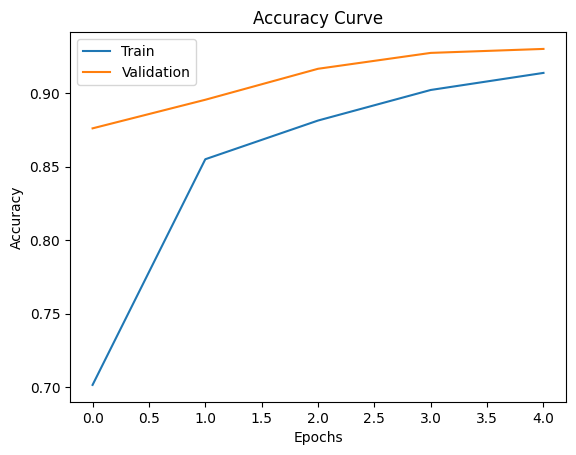

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend(['Train', 'Validation'])
plt.title("Accuracy Curve")
plt.show()


In [10]:
img_path = "/kaggle/input/datasets/disha1510/plant-disease-detection-dataset/test/TomatoEarlyBlight1.JPG"


In [11]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)


In [ ]:
prediction = model.predict(img_array)

class_names = train_ds.class_names
predicted_class = class_names[np.argmax(prediction)]

print("Predicted disease:", predicted_class)


In [ ]:
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}")
plt.axis("off")
plt.show()


In [12]:
import tensorflow as tf
import numpy as np

In [13]:
train_dir = "/kaggle/input/datasets/disha1510/plant-disease-detection-dataset/train/Tomato"
val_dir   = "/kaggle/input/datasets/disha1510/plant-disease-detection-dataset/valid/Tomato"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224,224),
    batch_size=16,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224,224),
    batch_size=32,
    shuffle=False
)

Found 7399 files belonging to 4 classes.
Found 1849 files belonging to 4 classes.


In [14]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224,224,3)),
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128,3,activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128,activation='relu'),
        tf.keras.layers.Dense(4,activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [15]:
def create_clients(dataset, num_clients):
    clients = []
    for i in range(num_clients):
        client_ds = dataset.shard(num_shards=num_clients, index=i)
        clients.append(client_ds)
    return clients

In [ ]:
def fed_avg(client_models):
    weights = [model.get_weights() for model in client_models]
    avg_weights = []

    for layer in zip(*weights):
        avg_weights.append(np.mean(layer, axis=0))

    return avg_weights

In [ ]:
import tensorflow.keras.backend as K
num_clients = 3
rounds = 8

clients = create_clients(train_ds, num_clients)

global_model_3 = create_model()

train_acc_3 = []
val_acc_3 = []

for r in range(rounds):
    print(f"\n🔵 Round {r+1} (3 Clients)")

    client_models = []
    client_train_acc = []

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model_3.get_weights())

        history = local_model.fit(client_data, epochs=1, verbose=0)

        train_acc = history.history['accuracy'][-1]
        client_train_acc.append(train_acc)

        client_models.append(local_model)

    # Avg training accuracy
    avg_train_acc = np.mean(client_train_acc)
    train_acc_3.append(avg_train_acc)

    # FedAvg
    avg_weights = fed_avg(client_models)
    global_model_3.set_weights(avg_weights)

    # Validation accuracy
    loss, val_acc = global_model_3.evaluate(val_ds, verbose=0)
    val_acc_3.append(val_acc)

    print(f"Round {r+1}: Train Acc={avg_train_acc:.4f}, Val Acc={val_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_acc_3, label="Train (3 clients)")
plt.plot(val_acc_3, label="Validation (3 clients)")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (3 Clients)")
plt.legend()
plt.show()

In [ ]:
num_clients = 9
rounds = 8

clients = create_clients(train_ds, num_clients)

# 🔥 IMPORTANT
global_model_9 = create_model()

train_acc_9 = []
val_acc_9 = []

for r in range(rounds):
    print(f"\n🟢 Round {r+1} (9 Clients)")

    client_models = []
    client_train_acc = []

    for i, client_data in enumerate(clients):
        print(f"Training client {i+1}")

        local_model = create_model()
        local_model.set_weights(global_model_9.get_weights())

        # Train
        history = local_model.fit(client_data, epochs=1, verbose=0)

        # Store training accuracy
        train_acc = history.history['accuracy'][-1]
        client_train_acc.append(train_acc)

        client_models.append(local_model)

    # 🔹 Average training accuracy across clients
    avg_train_acc = np.mean(client_train_acc)
    train_acc_9.append(avg_train_acc)

    # 🔹 FedAvg aggregation
    avg_weights = fed_avg(client_models)
    global_model_9.set_weights(avg_weights)

    # 🔹 Validation accuracy
    loss, val_acc = global_model_9.evaluate(val_ds, verbose=0)
    val_acc_9.append(val_acc)

    print(f"Round {r+1}: Train Acc = {avg_train_acc:.4f}, Val Acc = {val_acc:.4f}")

In [ ]:
import matplotlib.pyplot as plt
plt.plot(train_acc_9, label="Train (9 clients)")
plt.plot(val_acc_9, label="Validation (9 clients)")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (9 Clients)")
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_acc_3, label="3 Clients")
plt.plot(train_acc_9, label="9 Clients")

plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.title("FedAvg Learning Accuracy")

plt.legend()
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
predictions = global_model_9.predict(val_ds)
predicted_classes = np.argmax(predictions, axis=1)

# True labels
true_labels = np.concatenate([y for x, y in val_ds], axis=0)

# Confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# 🔥 FIX: define class names
class_names = val_ds.class_names

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - FedAvg (9 Clients)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    true_labels,
    predicted_classes,
    target_names=class_names
))

In [ ]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(true_labels, predicted_classes)
print("Accuracy:", acc)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(true_labels, predicted_classes, average='weighted')
recall = recall_score(true_labels, predicted_classes, average='weighted')
f1 = f1_score(true_labels, predicted_classes, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

In [ ]:
precision = precision_score(true_labels, predicted_classes, average=None)
recall = recall_score(true_labels, predicted_classes, average=None)
f1 = f1_score(true_labels, predicted_classes, average=None)

for i, class_name in enumerate(class_names):
    print(f"{class_name}:")
    print(f" Precision: {precision[i]:.3f}")
    print(f" Recall: {recall[i]:.3f}")
    print(f" F1-score: {f1[i]:.3f}")
    print()

In [ ]:
import matplotlib.pyplot as plt

x = range(len(class_names))

plt.bar(x, precision, width=0.2, label='Precision')
plt.bar([i+0.2 for i in x], recall, width=0.2, label='Recall')
plt.bar([i+0.4 for i in x], f1, width=0.2, label='F1-score')

plt.xticks([i+0.2 for i in x], class_names, rotation=30)
plt.ylabel("Score")
plt.title("Class-wise Metrics")
plt.legend()
plt.show()

In [ ]:
import tensorflow as tf

def fedprox_train(local_model, global_weights, dataset, mu=0.01):
    optimizer = tf.keras.optimizers.Adam(1e-4)

    for images, labels in dataset:
        with tf.GradientTape() as tape:
            preds = local_model(images, training=True)

            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(labels, preds)
            )

            # 🔥 Proximal term (efficient)
            prox_term = tf.add_n([
                tf.reduce_sum(tf.square(w - w_global))
                for w, w_global in zip(local_model.trainable_weights, global_weights)
            ])

            loss += (mu / 2) * prox_term

        grads = tape.gradient(loss, local_model.trainable_weights)
        optimizer.apply_gradients(zip(grads, local_model.trainable_weights))

In [ ]:
import numpy as np
from tensorflow.keras import backend as K

num_clients = 3
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_3 = []

for r in range(rounds):
    print(f"\nRound {r+1} - FedProx (3 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        fedprox_train(local_model, global_model.get_weights(), client_data)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    # Average
    avg_weights = [w / num_clients for w in sum_weights]
    global_model.set_weights(avg_weights)

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_3.append(acc)

    print("Val Acc:", acc)

# save results
np.save("fedprox_3.npy", val_acc_3)

In [ ]:
num_clients = 9
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_9 = []

for r in range(rounds):
    print(f"\nRound {r+1} - FedProx (9 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        fedprox_train(local_model, global_model.get_weights(), client_data)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    avg_weights = [w / num_clients for w in sum_weights]
    global_model.set_weights(avg_weights)

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_9.append(acc)

    print("Val Acc:", acc)

# save results
np.save("fedprox_9.npy", val_acc_9)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# load saved results
val_acc_3 = np.load("fedprox_3.npy")
val_acc_9 = np.load("fedprox_9.npy")

rounds = range(1, len(val_acc_3) + 1)

plt.figure(figsize=(8,5))

plt.plot(rounds, val_acc_3, marker='o', label='FedProx (3 Clients)')
plt.plot(rounds, val_acc_9, marker='o', label='FedProx (9 Clients)')

plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("FedProx: 3 vs 9 Clients")

plt.legend()
plt.grid()

plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import backend as K

num_clients = 3
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_3_adam = []

# 🔥 Server optimizer
server_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

for r in range(rounds):
    print(f"\nRound {r+1} - FedAdam (3 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        # Local training
        local_model.fit(client_data, epochs=1, verbose=0)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    # Average weights
    avg_weights = [w / num_clients for w in sum_weights]

    # 🔥 Compute gradients (difference)
    grads = [gw - aw for gw, aw in zip(global_model.get_weights(), avg_weights)]

    # 🔥 Apply server-side Adam update
    server_optimizer.apply_gradients(zip(grads, global_model.trainable_weights))

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_3_adam.append(acc)

    print("Val Acc:", acc)

# save
np.save("fedadam_3.npy", val_acc_3_adam)

In [25]:
num_clients = 9
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_9_adam = []

server_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

for r in range(rounds):
    print(f"\nRound {r+1} - FedAdam (9 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        local_model.fit(client_data, epochs=1, verbose=0)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    avg_weights = [w / num_clients for w in sum_weights]

    grads = [gw - aw for gw, aw in zip(global_model.get_weights(), avg_weights)]

    server_optimizer.apply_gradients(zip(grads, global_model.trainable_weights))

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_9_adam.append(acc)

    print("Val Acc:", acc)

# save
np.save("fedadam_9.npy", val_acc_9_adam)


Round 1 - FedAdam (9 Clients)
Val Acc: 0.5116279125213623

Round 2 - FedAdam (9 Clients)
Val Acc: 0.5792320370674133

Round 3 - FedAdam (9 Clients)
Val Acc: 0.5889670252799988

Round 4 - FedAdam (9 Clients)
Val Acc: 0.6095186471939087

Round 5 - FedAdam (9 Clients)
Val Acc: 0.6078961491584778

Round 6 - FedAdam (9 Clients)
Val Acc: 0.5808545351028442

Round 7 - FedAdam (9 Clients)
Val Acc: 0.6160086393356323

Round 8 - FedAdam (9 Clients)
Val Acc: 0.7138994336128235


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

val_acc_3 = np.load("fedadam_3.npy")
val_acc_9 = np.load("fedadam_9.npy")

rounds = range(1, len(val_acc_3) + 1)

plt.figure(figsize=(8,5))

plt.plot(rounds, val_acc_3, marker='o', label='FedAdam (3 Clients)')
plt.plot(rounds, val_acc_9, marker='o', label='FedAdam (9 Clients)')

plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("FedAdam: 3 vs 9 Clients")

plt.legend()
plt.grid()

plt.show()

In [16]:
import tensorflow as tf

def feddyn_train(local_model, global_weights, dataset, alpha=0.01):
    optimizer = tf.keras.optimizers.Adam(1e-4)

    for images, labels in dataset:
        with tf.GradientTape() as tape:
            preds = local_model(images, training=True)

            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(labels, preds)
            )

            # 🔥 Dynamic term
            dyn_term = tf.add_n([
                tf.reduce_sum(w * w_global)
                for w, w_global in zip(local_model.trainable_weights, global_weights)
            ])

            loss -= alpha * dyn_term

        grads = tape.gradient(loss, local_model.trainable_weights)
        optimizer.apply_gradients(zip(grads, local_model.trainable_weights))

In [17]:
import numpy as np
from tensorflow.keras import backend as K

num_clients = 3
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_3_dyn = []

for r in range(rounds):
    print(f"\nRound {r+1} - FedDyn (3 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        feddyn_train(local_model, global_model.get_weights(), client_data)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    avg_weights = [w / num_clients for w in sum_weights]
    global_model.set_weights(avg_weights)

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_3_dyn.append(acc)

    print("Val Acc:", acc)

np.save("feddyn_3.npy", val_acc_3_dyn)


Round 1 - FedDyn (3 Clients)
Val Acc: 0.7685235142707825

Round 2 - FedDyn (3 Clients)
Val Acc: 0.8388317823410034

Round 3 - FedDyn (3 Clients)
Val Acc: 0.8685775995254517

Round 4 - FedDyn (3 Clients)
Val Acc: 0.8972417712211609

Round 5 - FedDyn (3 Clients)
Val Acc: 0.897782564163208

Round 6 - FedDyn (3 Clients)
Val Acc: 0.9075175523757935

Round 7 - FedDyn (3 Clients)
Val Acc: 0.9123850464820862

Round 8 - FedDyn (3 Clients)
Val Acc: 0.9123850464820862


In [18]:
from tensorflow.keras import backend as K
num_clients = 9
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_9_dyn = []

for r in range(rounds):
    print(f"\nRound {r+1} - FedDyn (9 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        feddyn_train(local_model, global_model.get_weights(), client_data)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    avg_weights = [w / num_clients for w in sum_weights]
    global_model.set_weights(avg_weights)

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_9_dyn.append(acc)

    print("Val Acc:", acc)

np.save("feddyn_9.npy", val_acc_9_dyn)


Round 1 - FedDyn (9 Clients)
Val Acc: 0.3039480745792389

Round 2 - FedDyn (9 Clients)
Val Acc: 0.7485126852989197

Round 3 - FedDyn (9 Clients)
Val Acc: 0.775554358959198

Round 4 - FedDyn (9 Clients)
Val Acc: 0.7912384867668152

Round 5 - FedDyn (9 Clients)
Val Acc: 0.794483482837677

Round 6 - FedDyn (9 Clients)
Val Acc: 0.8177393078804016

Round 7 - FedDyn (9 Clients)
Val Acc: 0.8204435110092163

Round 8 - FedDyn (9 Clients)
Val Acc: 0.8312601447105408


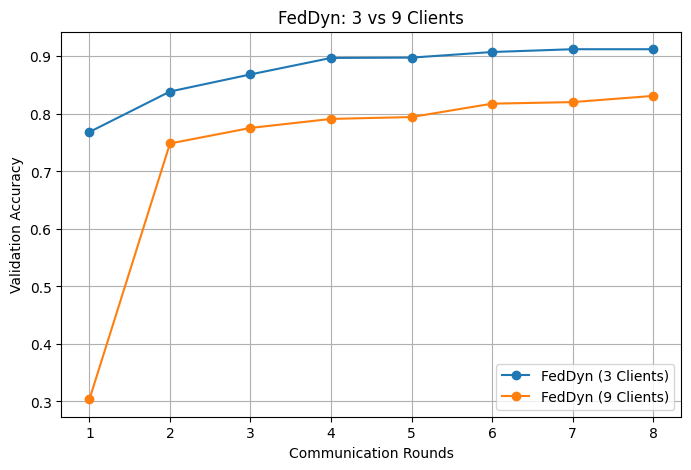

In [19]:
import numpy as np
import matplotlib.pyplot as plt

val_acc_3 = np.load("feddyn_3.npy")
val_acc_9 = np.load("feddyn_9.npy")

rounds = range(1, len(val_acc_3) + 1)

plt.figure(figsize=(8,5))

plt.plot(rounds, val_acc_3, marker='o', label='FedDyn (3 Clients)')
plt.plot(rounds, val_acc_9, marker='o', label='FedDyn (9 Clients)')

plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("FedDyn: 3 vs 9 Clients")

plt.legend()
plt.grid()

plt.show()

In [20]:
import tensorflow as tf

def fedsgd_train(local_model, dataset):
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

    for images, labels in dataset.take(1):   # 🔥 only 1 batch
        with tf.GradientTape() as tape:
            preds = local_model(images, training=True)

            loss = tf.reduce_mean(
                tf.keras.losses.sparse_categorical_crossentropy(labels, preds)
            )

        grads = tape.gradient(loss, local_model.trainable_weights)
        optimizer.apply_gradients(zip(grads, local_model.trainable_weights))

In [21]:
import numpy as np
from tensorflow.keras import backend as K

num_clients = 3
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_3_sgd = []

for r in range(rounds):
    print(f"\nRound {r+1} - FedSGD (3 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        fedsgd_train(local_model, client_data)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    avg_weights = [w / num_clients for w in sum_weights]
    global_model.set_weights(avg_weights)

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_3_sgd.append(acc)

    print("Val Acc:", acc)

np.save("fedsgd_3.npy", val_acc_3_sgd)


Round 1 - FedSGD (3 Clients)
Val Acc: 0.2671714425086975

Round 2 - FedSGD (3 Clients)
Val Acc: 0.2628447711467743

Round 3 - FedSGD (3 Clients)
Val Acc: 0.2682531177997589

Round 4 - FedSGD (3 Clients)
Val Acc: 0.27366143465042114

Round 5 - FedSGD (3 Clients)
Val Acc: 0.2655489444732666

Round 6 - FedSGD (3 Clients)
Val Acc: 0.2504056394100189

Round 7 - FedSGD (3 Clients)
Val Acc: 0.2866414189338684

Round 8 - FedSGD (3 Clients)
Val Acc: 0.2504056394100189


In [22]:
num_clients = 9
rounds = 8

clients = create_clients(train_ds, num_clients)
global_model = create_model()

val_acc_9_sgd = []

for r in range(rounds):
    print(f"\nRound {r+1} - FedSGD (9 Clients)")

    sum_weights = None

    for i, client_data in enumerate(clients):
        local_model = create_model()
        local_model.set_weights(global_model.get_weights())

        fedsgd_train(local_model, client_data)

        weights = local_model.get_weights()

        if sum_weights is None:
            sum_weights = weights
        else:
            sum_weights = [sw + w for sw, w in zip(sum_weights, weights)]

        # 🔥 free memory
        del local_model
        K.clear_session()

    avg_weights = [w / num_clients for w in sum_weights]
    global_model.set_weights(avg_weights)

    loss, acc = global_model.evaluate(val_ds, verbose=0)
    val_acc_9_sgd.append(acc)

    print("Val Acc:", acc)

np.save("fedsgd_9.npy", val_acc_9_sgd)


Round 1 - FedSGD (9 Clients)
Val Acc: 0.2623039484024048

Round 2 - FedSGD (9 Clients)
Val Acc: 0.2687939405441284

Round 3 - FedSGD (9 Clients)
Val Acc: 0.37912383675575256

Round 4 - FedSGD (9 Clients)
Val Acc: 0.2871822714805603

Round 5 - FedSGD (9 Clients)
Val Acc: 0.29637640714645386

Round 6 - FedSGD (9 Clients)
Val Acc: 0.2504056394100189

Round 7 - FedSGD (9 Clients)
Val Acc: 0.3515413701534271

Round 8 - FedSGD (9 Clients)
Val Acc: 0.2504056394100189


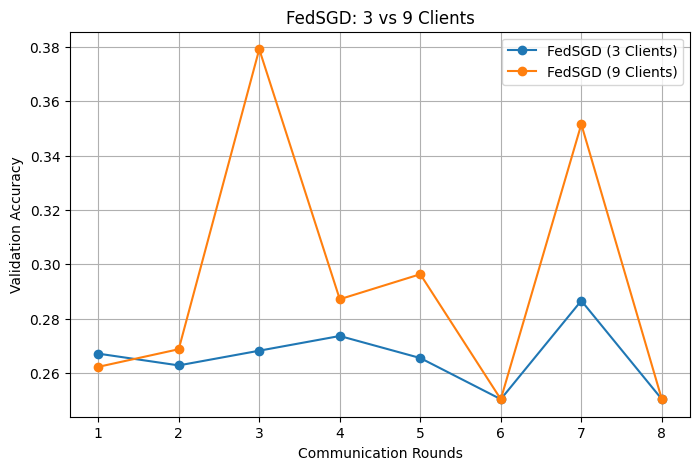

In [23]:
import numpy as np
import matplotlib.pyplot as plt

val_acc_3 = np.load("fedsgd_3.npy")
val_acc_9 = np.load("fedsgd_9.npy")

rounds = range(1, len(val_acc_3) + 1)

plt.figure(figsize=(8,5))

plt.plot(rounds, val_acc_3, marker='o', label='FedSGD (3 Clients)')
plt.plot(rounds, val_acc_9, marker='o', label='FedSGD (9 Clients)')

plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("FedSGD: 3 vs 9 Clients")

plt.legend()
plt.grid()

plt.show()

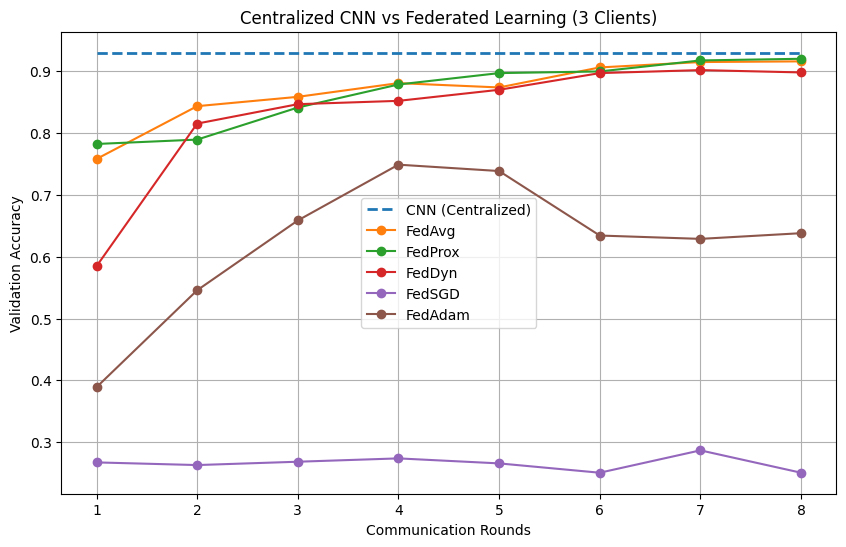

In [24]:
import matplotlib.pyplot as plt

rounds = list(range(1, 9))

# ✅ CNN baseline (constant line)
cnn_acc = [0.9302] * 8

#FedAvg
fedavg = [0.7582, 0.8437, 0.8588, 0.8810, 0.8740, 0.9064, 0.9151, 0.9162]

# FedProx
fedprox = [0.7825, 0.7896, 0.8415, 0.8788, 0.8972, 0.8999, 0.9177, 0.9204]

# FedDyn
feddyn = [0.5846, 0.8155, 0.8469, 0.8523, 0.8702, 0.8972, 0.9021, 0.8983]

# FedSGD
fedsgd = [0.2671, 0.2628, 0.2682, 0.2736, 0.2655, 0.2504, 0.2866, 0.2504]

# FedAdam
fedadam = [0.3888, 0.5457, 0.6587, 0.7490, 0.7387, 0.6343, 0.6289, 0.6381]


plt.figure(figsize=(10,6))

# 🔥 CNN baseline (dashed)
plt.plot(rounds, cnn_acc, linestyle='--', linewidth=2, label='CNN (Centralized)')
plt.plot(rounds, fedavg, marker='o', label='FedAvg')
plt.plot(rounds, fedprox, marker='o', label='FedProx')
plt.plot(rounds, feddyn, marker='o', label='FedDyn')
plt.plot(rounds, fedsgd, marker='o', label='FedSGD')
plt.plot(rounds, fedadam, marker='o', label='FedAdam')

plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("Centralized CNN vs Federated Learning (3 Clients)")

plt.legend()
plt.grid()

plt.show()

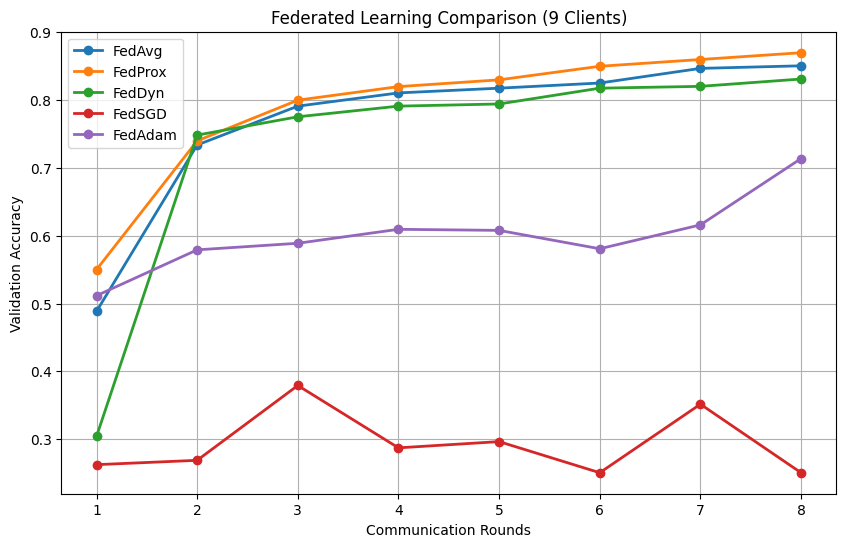

In [26]:
import matplotlib.pyplot as plt

rounds = list(range(1, 9))

# ✅ FedAvg (from your logs)
fedavg = [0.4884, 0.7339, 0.7912, 0.8107, 0.8177, 0.8253, 0.8469, 0.8507]

#FedProx
fedprox = [0.55,0.74,0.80,0.82,0.83,0.85,0.86,0.87]

# ✅ FedDyn
feddyn = [0.3039, 0.7485, 0.7755, 0.7912, 0.7944, 0.8177, 0.8204, 0.8312]

# ✅ FedSGD
fedsgd = [0.2623, 0.2687, 0.3791, 0.2871, 0.2963, 0.2504, 0.3515, 0.2504]

# ✅ FedAdam
fedadam = [0.5116, 0.5792, 0.5889, 0.6095, 0.6079, 0.5808, 0.6160, 0.7138]


plt.figure(figsize=(10,6))

plt.plot(rounds, fedavg, marker='o', linewidth=2, label='FedAvg')
plt.plot(rounds, fedprox, marker='o', linewidth=2, label='FedProx')
plt.plot(rounds, feddyn, marker='o', linewidth=2, label='FedDyn')
plt.plot(rounds, fedsgd, marker='o', linewidth=2, label='FedSGD')
plt.plot(rounds, fedadam, marker='o', linewidth=2, label='FedAdam')

plt.xlabel("Communication Rounds")
plt.ylabel("Validation Accuracy")
plt.title("Federated Learning Comparison (9 Clients)")

plt.legend()
plt.grid()

plt.show()

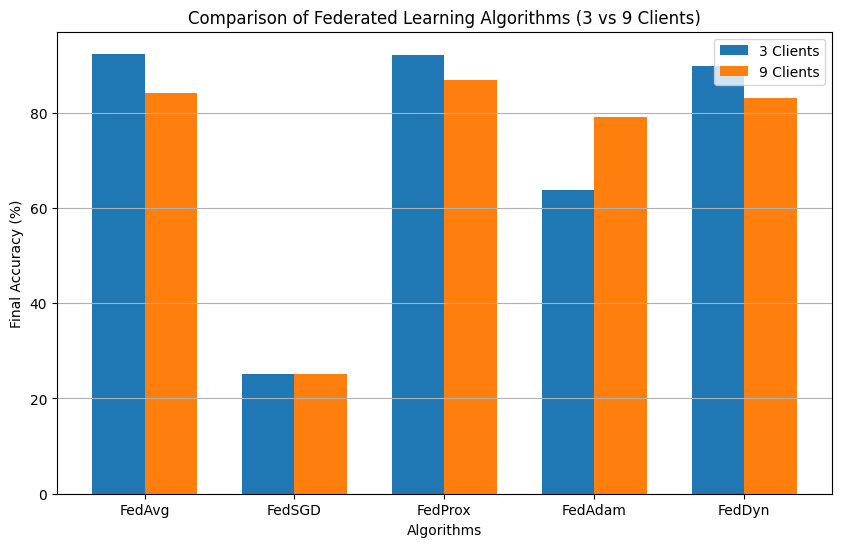

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Algorithms
algos = ['FedAvg', 'FedSGD', 'FedProx', 'FedAdam', 'FedDyn']

# Final Accuracy (from your table)
acc_3 = [92.34, 25.04, 92.04, 63.81, 89.83]
acc_9 = [84.18, 25.04, 86.85, 78.96, 83.12]

x = np.arange(len(algos))
width = 0.35

plt.figure(figsize=(10,6))

# Bars
plt.bar(x - width/2, acc_3, width, label='3 Clients')
plt.bar(x + width/2, acc_9, width, label='9 Clients')

# Labels
plt.xlabel("Algorithms")
plt.ylabel("Final Accuracy (%)")
plt.title("Comparison of Federated Learning Algorithms (3 vs 9 Clients)")
plt.xticks(x, algos)

plt.legend()
plt.grid(axis='y')

plt.show()

In [28]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[389  20   0  16]
 [  7 423   0  50]
 [  0   2 474   5]
 [  0  26   3 434]]


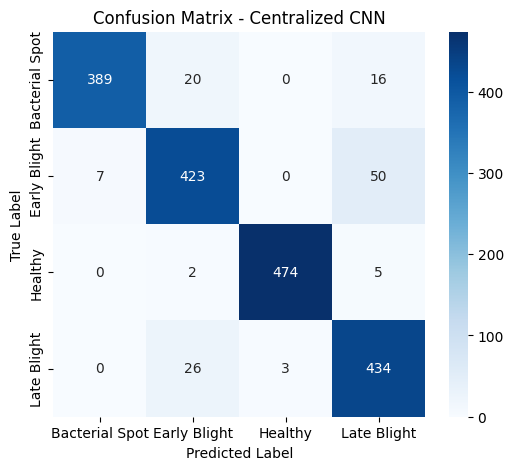

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

class_names = train_ds.class_names  # ['Bacterial Spot', 'Early Blight', ...]

plt.figure(figsize=(6,5))

sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Centralized CNN")

plt.show()